
<style>
  .capa{max-width:920px;margin:16px auto;padding:24px;border:1px solid #e5e7eb;border-radius:12px;font-family:system-ui,-apple-system,"Segoe UI",Roboto,Arial,sans-serif;color:#1f2937}
  .topo{display:flex;gap:16px;align-items:center}
  .logo{width:120px;height:auto;border:1px solid #e5e7eb;border-radius:6px;padding:6px;background:#fff}
  h1{margin:0 0 4px 0;font-size:24px;color:#111827}
  .sub{color:#6b7280;margin-bottom:10px}
  .meta{display:flex;flex-wrap:wrap;gap:8px;margin-bottom:12px}
  .pill{font-size:12px;padding:6px 10px;border:1px solid #e5e7eb;border-radius:999px;background:#f3f4f6}
  hr{border:none;border-top:1px solid #e5e7eb;margin:14px 0}
  h2{font-size:16px;margin:0 0 6px 0;color:#111827}
  ul{margin:6px 0 0 18px}
</style>

<div class="capa" role="region" aria-label="Capa UFMG">
  <div class="topo">
    <img class="logo" src="logo_ufmg.png" alt="Logo UFMG">
    <div>
      <h1>TCC — Análise Descritiva de Preços de Combustíveis (ANP)</h1>
      <div class="sub">Universidade Federal de Minas Gerais — Nota sobre viés e limitações</div>
      <div class="meta">
        <span class="pill">Autoria: <b>Marina Ferreira</b></span>
        <span class="pill">Orientação: <b>Profa. Dra. Jussiane</b></span>
        <span class="pill">Versão 1.0</span>
      </div>
    </div>
  </div>

  <hr>

  <h2>Introdução</h2>
  <p>Este caderno consolida estatísticas descritivas de <em>preços de combustíveis</em> ao longo dos anos,
  com granularidade principal <b>anual</b> e recortes por <b>produto</b> e por <b>espaço</b> (regiões, UFs, municípios).
  O objetivo é apoiar a narrativa de eventos de mercado e políticas públicas que possam ter influenciado
  essas variações.</p>

  <h2>Principais vieses e limitações</h2>
  <ul>
    <li><b>Agregação anual</b> suaviza choques intra-ano; usarei também série mensal.</li>
    <li><b>Cobertura amostral</b> desigual entre UFs/municípios/produtos (impacta comparabilidade).</li>
    <li><b>Rotatividade de postos</b> altera o mix de observações (viés de sobrevivência).</li>
    <li><b>Erros de medição</b> podem persistir mesmo após filtros de outliers.</li>
    <li><b>Tributos e políticas</b> não são controlados automaticamente; interpretar com contexto.</li>
    <li><b>Heterogeneidade espacial</b> (logística/concorrência/renda) afeta níveis de preço.</li>
    <li><b>Composição por produto</b> (ex.: aditivados) influencia médias.</li>
      <li><b>Comparativo de preço de compra com venda</b> não tem registro suficiente de preço de compra e também não tem registro para todos os anos parando em 2020. Por isso a coluna não será usada.</li>
  </ul>

  <h2>Notas metodológicas (resumo)</h2>
  <ul>
    <li>Limpeza monetária (R$) e padronização decimal.</li>
    <li>Cálculos por <em>ano × produto</em> e recortes espaciais; média, mediana, desvio-padrão, p10, p90, IQR e <i>n</i>.</li>
    <li>Outliers por IQR apenas para diagnóstico.</li>
    <li>Mapas com <code>geopandas</code> + <code>geobr</code>; <i>join</i> municipal por nome dentro da UF.</li>
    <li>Série mensal disponível para anotar eventos (políticas/choques).</li>
     <li>Código comentado por IA.</li>
  </ul>
</div>


In [1]:
import pandas as pd
import folium
#import great_expectations
from pathlib import Path
from zipfile import ZipFile
import os
from pathlib import Path
from typing import Optional, Sequence
import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from scipy import stats

from statsmodels.api import OLS, add_constant
from statsmodels.stats.outliers_influence import OLSInfluence, variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, het_white, linear_reset
from statsmodels.stats.stattools import jarque_bera, durbin_watson
from patsy import dmatrices
import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy.contrasts import Treatment
from statsmodels.stats.diagnostic import het_breuschpagan, het_white, linear_reset
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF

# Configuração do Notebook
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.options.mode.chained_assignment = None
pd.set_option("display.width", 120)

In [2]:
def check_cols(df, columns=None):
    """
    Returns a summary of column properties: dtype, unique values, number and percentage of NaNs.

    Parameters:
    - df (pd.DataFrame): The dataframe to inspect.
    - columns (list or None): Subset of columns to check. If None, checks all columns.

    Returns:
    - pd.DataFrame: A summary dataframe sorted by the number of NaN values.
    """
    if columns is None:
        columns = df.columns

    nunique_safe = df[columns].apply(lambda col: col.astype(str).nunique())
    dtypes = df[columns].dtypes
    nans = df[columns].isna().sum()
    percent_nans = round((nans / df.shape[0]) * 100, 2)

    df_check = pd.DataFrame({
        'Variável': columns,
        'Tipo': dtypes,
        'Qtde_unicos': nunique_safe,
        'Qtde_NaN': nans,
        '%_NaN': percent_nans
    })

    return df_check.sort_values('Qtde_NaN').reset_index(drop=True)

def remove_accents(a):
    import unidecode
    return unidecode.unidecode(a.encode().decode('utf-8')).upper().strip()

def normalize_col(c):
    c = str(c).strip()
    c = unicodedata.normalize("NFKD", c).encode("ascii", "ignore").decode("ascii")
    c = c.lower()
    c = re.sub(r"[\s\-\/]+", "_", c)
    c = re.sub(r"[^0-9a-z_]", "", c)
    c = re.sub(r"_+", "_", c).strip("_")
    return c

def extract_all_zips(folder, recursive=True, delete_zip=False):
    """
    Descompacta todos os .zip da pasta (e subpastas se recursive=True).
    Extrai no próprio 'folder'. Opcionalmente remove os .zip após extrair.
    Retorna uma lista de arquivos extraídos.
    """
    base = Path(folder).resolve()
    pattern = "**/*.zip" if recursive else "*.zip"
    extracted = []

    for zpath in sorted(base.glob(pattern)):
        with ZipFile(zpath) as zf:
            # segurança: evita path traversal
            for m in zf.infolist():
                target = (base / m.filename).resolve()
                if not str(target).startswith(str(base)):
                    raise RuntimeError(f"Entrada suspeita no ZIP: {m.filename}")
            zf.extractall(path=base)
            extracted.extend([str((base / m.filename).resolve()) for m in zf.infolist() if m.filename.lower().endswith(".csv")])
        if delete_zip:
            zpath.unlink()
    return extracted

def concatenar_csvs_da_pasta(caminho_da_pasta, nome_arquivo_saida, separador=';', encodings_a_tentar=['utf-8-sig', 'latin1', 'iso-8859-1']):
    """
    Tenta concatenar todos os arquivos CSV de uma pasta, lidando com diferentes
    codificações e erros de formatação nas linhas.

    Args:
        caminho_da_pasta (str): O caminho do diretório contendo os arquivos CSV.
        nome_arquivo_saida (str): O nome do arquivo CSV de saída para salvar o resultado.
        separador (str): O caractere separador dos campos (ponto e vírgula, vírgula, etc.).
        encodings_a_tentar (list): Lista de codificações a serem tentadas.

    Returns:
        pd.DataFrame: O DataFrame pandas resultante da concatenação.
    """
    # Lista para armazenar os DataFrames de cada arquivo CSV
    lista_dataframes = []
    arquivos_com_erro = []

    # Itera sobre todos os arquivos no diretório
    for arquivo in os.listdir(caminho_da_pasta):
        # Verifica se o arquivo é um CSV
        if arquivo.endswith('.csv'):
            caminho_completo_arquivo = os.path.join(caminho_da_pasta, arquivo)
            print(f'Lendo o arquivo: {caminho_completo_arquivo}')
            
            df_temporario = None
            leitura_bem_sucedida = False
            
            # Tenta ler o arquivo com diferentes codificações
            for encoding in encodings_a_tentar:
                try:
                    df_temporario = pd.read_csv(
                        caminho_completo_arquivo,
                        encoding=encoding,
                        sep=separador,
                        on_bad_lines='skip', # Ignora linhas com erros de formatação
                        low_memory=False # Ajuda a evitar erros de tipo em datasets grandes
                    )
                    lista_dataframes.append(df_temporario)
                    print(f"Sucesso com o separador '{separador}' e codificação '{encoding}'.")
                    leitura_bem_sucedida = True
                    break # Sai do loop de encodings se a leitura foi bem-sucedida
                except Exception as e:
                    continue # Tenta a próxima codificação se houver um erro

            if not leitura_bem_sucedida:
                print(f"Falha ao ler o arquivo {arquivo} com os parâmetros fornecidos.")
                arquivos_com_erro.append(arquivo)
                
    # Verifica se a lista de DataFrames não está vazia
    if not lista_dataframes:
        print("Nenhum arquivo CSV pôde ser lido na pasta.")
        return pd.DataFrame()

    # Concatena todos os DataFrames da lista em um único DataFrame
    df_final = pd.concat(lista_dataframes, ignore_index=True)
    print(f'\nConcluído! {len(lista_dataframes)} arquivos foram lidos e concatenados.')
    print(f'O DataFrame final tem {len(df_final)} linhas.')
    
    if arquivos_com_erro:
        print(f"Os seguintes arquivos não puderam ser lidos: {', '.join(arquivos_com_erro)}")

    # Salva o DataFrame final em um novo arquivo CSV
    df_final.to_csv(nome_arquivo_saida, index=False)
    print(f'O DataFrame concatenado foi salvo em: {nome_arquivo_saida}')

    return df_final



# Função para criar e salvar gráficos de barras
def plot_bar_chart(df, group_col, value_col, title, filename):
    import seaborn as sns
    plt.figure(figsize=(12, 8))
    # Agrupar e somar os valores para plotagem
    grouped_data = df.groupby(group_col)[value_col].sum().sort_values(ascending=False)
    sns.barplot(x=grouped_data.index, y=grouped_data.values, palette='viridis')
    plt.title(title)
    plt.xlabel(group_col)
    plt.ylabel(f'Soma do {value_col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(filename)
    plt.close()

Dados:  </br>
https://www.gov.br/anp/pt-br/assuntos/precos-e-defesa-da-concorrencia/precos/levantamento-de-precos-de-combustiveis-ultimas-semanas-pesquisadas </br>
-> serie historica https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/serie-historica-de-precos-de-combustiveis

In [3]:
from pathlib import Path


def read_parquet_smart(path_or_dir: str, filename: str | None = None):
    # tenta pyarrow; cai para fastparquet
    try:
        import pyarrow  # noqa
        engine = "pyarrow"
    except Exception:
        engine = "fastparquet"

    p = Path(path_or_dir).expanduser().resolve()

    # 1) Se path_or_dir já é um arquivo .parquet → lê direto
    if p.is_file() and p.suffix.lower() == ".parquet":
        df = pd.read_parquet(p, engine=engine)
        print(f"[OK] Lido arquivo: {p} ({engine})")
        return df

    # 2) Se for diretório:
    if p.is_dir():
        if filename:  # arquivo específico dentro da pasta
            alvo = p / filename
            if alvo.exists():
                df = pd.read_parquet(alvo, engine=engine)
                print(f"[OK] Lido arquivo: {alvo} ({engine})")
                return df
        # 2b) dataset particionado (pasta parquet) com o nome sem .parquet
        if filename and (p / filename.replace(".parquet", "")).is_dir():
            df = pd.read_parquet(p / filename.replace(".parquet", ""), engine=engine)
            print(f"[OK] Lido dataset particionado: {p/filename.replace('.parquet','')} ({engine})")
            return df
        # 2c) senão, pega o primeiro .parquet da pasta
        candidatos = sorted(p.glob("*.parquet"))
        if candidatos:
            df = pd.read_parquet(candidatos[0], engine=engine)
            print(f"[OK] Lido primeiro parquet da pasta: {candidatos[0]} ({engine})")
            return df
        raise FileNotFoundError(f"Nenhum .parquet encontrado em: {p}")

    raise FileNotFoundError(f"Caminho inválido (não é arquivo .parquet nem pasta): {p}")


In [4]:
pasta = "/home/mari/tcc_lubricants_anp"
arquivo = "lubricants_anp_full.parquet"
df_raw = read_parquet_smart(pasta, filename=arquivo)

[OK] Lido arquivo: /home/mari/tcc_lubricants_anp/lubricants_anp_full.parquet (pyarrow)


In [5]:
df_raw = df_raw.loc[:, ~df_raw.columns.str.match(r"^Unnamed")]

In [6]:
df = df_raw.copy()

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7422035 entries, 0 to 7422034
Data columns (total 16 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   Regiao - Sigla     object
 1   Estado - Sigla     object
 2   Municipio          object
 3   Revenda            object
 4   CNPJ da Revenda    object
 5   Nome da Rua        object
 6   Numero Rua         object
 7   Complemento        object
 8   Bairro             object
 9   Cep                object
 10  Produto            object
 11  Data da Coleta     object
 12  Valor de Venda     object
 13  Valor de Compra    object
 14  Unidade de Medida  object
 15  Bandeira           object
dtypes: object(16)
memory usage: 906.0+ MB


In [8]:
df_raw.sample(5)

,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
1379673,CO,GO,GOIANIA,AUTO POSTO DONA SANTA LTDA.,08.232.672/0001-34,AVENIDA T 63,1295,ESQUINA C/ AVENIDA T-15,NOVA SUIÇA,74280-235,ETANOL,30/09/2021,"4,97",None,R$ / litro,BRANCA
969390,S,RS,CANOAS,RW COMERCIAL DE COMBUSTIVEIS LTDA,15.162.023/0001-70,RUA FERNANDO FERRARI,1790,None,NITEROI,92130-000,GASOLINA ADITIVADA,01/09/2022,"4,91",None,R$ / litro,VIBRA ENERGIA
4551187,SE,MG,GOVERNADOR VALADARES,REDE HG COMBUSTIVEIS LTDA.,13.569.064/0008-26,AVENIDA RIO/BAHIA,S/N,KM: 420 E 56 METROS;,VILA ISA,35044-000,ETANOL,13/03/2017,"3,059",None,R$ / litro,RAIZEN
526030,CO,MS,TRES LAGOAS,MOTA COMERCIO DE COMBUSTIVEL LTDA,10.696.553/0001-84,RUA JOSE PALMA,52,None,SANTOS DUMONT,79601-970,DIESEL S10,18/07/2017,"3,498",None,R$ / litro,PETROBRAS DISTRIBUIDORA S.A.
901577,SE,SP,MATAO,AUTO POSTO 21 DE MATAO LTDA,03.687.679/0001-27,RUA SAO LOURENCO,380,None,CENTRO,15990-005,ETANOL,11/08/2022,"3,75",None,R$ / litro,BRANCA


In [9]:
check_cols(df, df.columns)

,Variável,Tipo,Qtde_unicos,Qtde_NaN,%_NaN
0,Regiao - Sigla,object,6,9114,0.12
1,Estado - Sigla,object,28,9114,0.12
2,Municipio,object,528,9114,0.12
3,Revenda,object,21642,9114,0.12
4,CNPJ da Revenda,object,23853,9114,0.12
5,Nome da Rua,object,13761,9114,0.12
6,Produto,object,7,9114,0.12
7,Cep,object,15864,9114,0.12
8,Bandeira,object,97,9114,0.12
9,Unidade de Medida,object,3,9114,0.12


In [10]:
df.head(1)

,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
0,SE,SP,SOROCABA,COMPETRO COMERCIO E DISTRIBUICAO DE DERIVADOS ...,00.003.188/0001-21,RUA HUMBERTO DE CAMPOS,306,None,JARDIM ZULMIRA,18061-000,GASOLINA,03/07/2023,"4,87",None,R$ / litro,BRANCA


In [11]:
# Padroniza nomes mais simples
rename_map = {
    "Regiao - Sigla":"regiao",
    "Estado - Sigla":"uf",
    "Municipio":"municipio",
    "Revenda":"revenda",
    "CNPJ da Revenda":"cnpj",
    "Nome da Rua":"logradouro",
    "Numero Rua":"numero",
    "Complemento":"complemento",
    "Bairro":"bairro",
    "Cep":"cep",
    "Produto":"produto",
    "Data da Coleta":"data",
    "Valor de Venda":"preco_venda",
    "Valor de Compra":"preco_compra",
    "Unidade de Medida":"unidade",
    "Bandeira":"bandeira"
}
df = df.rename(columns=rename_map)

# Converte data (formato DD/MM/AAAA)
df["data"] = pd.to_datetime(df["data"], format="%d/%m/%Y", errors="coerce")

# >>> CORTE TEMPORAL PARA EQUALIZAR (somente dados a partir de 2021-01-01)
cutoff = pd.Timestamp("2021-01-01")
df = df.loc[df["data"] >= cutoff].copy()

# Conversor pt-BR -> numérico
def _to_num(x):
    if pd.isna(x):
        return np.nan
    s = (
        str(x)
        .replace("R$", "")
        .replace("r$", "")
        .replace(" ", "")
        .replace(".", "")   # remove milhar
        .replace(",", ".")  # vírgula -> ponto decimal
    )
    try:
        return float(s)
    except:
        return np.nan

# Converte preços
df["preco_venda"]  = df["preco_venda"].apply(_to_num)
if "preco_compra" in df.columns:
    df["preco_compra"] = df["preco_compra"].apply(_to_num)

# Remove linhas sem data ou sem preço de venda
df = df.dropna(subset=["data", "preco_venda"]).copy()

In [12]:
# (Opcional) remove valores impossíveis (ex.: negativos, zeros)
df = df.loc[df["preco_venda"] > 0].copy()

# (Opcional) campos úteis para modelagem agregada
df["ano"]    = df["data"].dt.year.astype("int16")
df["mes_dt"] = df["data"].dt.to_period("M").dt.to_timestamp()
df["sem_dt"] = df["data"].dt.to_period("W-MON").apply(lambda p: p.start_time)

In [ ]:
min_data_gas_aditivada = df.loc[df['produto'].eq('GASOLINA ADITIVADA'), 'data'].min()

print(min_data_gas_aditivada)                 # Timestamp
print(min_data_gas_aditivada.strftime('%Y-%m-%d'))  # em string, se preferir


2021-01-01 00:00:00
2021-01-01


essa edicao para o modelo foi pensada porque nao tem dados da gasolina aditivada de antes de 10/2020, portanto, achei melhor equalizar todos os produtos a partir de 2021, usando os dados de 21-24 para prever 25. Ainda assim um bom range. 

In [13]:
df.sample(5)

,regiao,uf,municipio,revenda,cnpj,logradouro,numero,complemento,bairro,cep,produto,data,preco_venda,preco_compra,unidade,bandeira,ano,mes_dt,sem_dt
3805375,SE,SP,PIRACICABA,POSTO PIRACICABAO COMERCIO DE COMBUSTIVEIS LTDA,01.548.277/0001-16,AVENIDA RIO DAS PEDRAS,530,None,PIRACICAMIRIM,13420-520,ETANOL,2023-05-17,3.390,NaN,R$ / litro,BRANCA,2023,2023-05-01,2023-05-16
2172219,S,RS,SANTANA DO LIVRAMENTO,RODRIGUES & STAEVIE COMERCIO DE COMBUSTIVEIS LTDA,27.425.152/0001-92,RUA PAUL HARRIS,58,None,FORTIM,97574-360,DIESEL S10,2021-02-02,3.999,NaN,R$ / litro,IPIRANGA,2021,2021-02-01,2021-02-02
828922,NE,CE,SOBRAL,COMERCIAL DE COMBUSTIVEIS TREZE DE MAIO LTDA,05.980.738/0001-86,AVENIDA JONH SANFORD,1943,None,JUNCO,62114-000,DIESEL S10,2022-07-20,7.990,NaN,R$ / litro,IPIRANGA,2022,2022-07-01,2022-07-19
4242960,SE,RJ,BELFORD ROXO,AUTO POSTO SANTORINI LTDA.,09.633.734/0001-82,RODOVIA PRESIDENTE DUTRA,10726,None,ROCHA SOBRINHO,26130-250,GNV,2024-11-14,4.690,NaN,R$ / m³,RAIZEN,2024,2024-11-01,2024-11-12
4042245,CO,MS,CORUMBA,COMERCIAL MIGUEIS DE DERIVADOS DE PETROLEO LTDA,26.824.433/0005-89,RUA DOM AQUINO,1515,None,CENTRO,79331-080,GASOLINA ADITIVADA,2024-08-19,7.180,NaN,R$ / litro,VIBRA,2024,2024-08-01,2024-08-13


In [14]:
# =========================================================
# 2) Agregação: mediana semanal por combustível
# =========================================================

# Define o início da semana (ISO: segunda-feira). Ajuste se preferir domingo.
# Usaremos "W-MON": períodos encerrando na segunda (i.e., janela [ter->seg]).
# Alternativa comum é "W-SUN"; escolha uma e mantenha consistente.
week_rule = "W-MON"

# Mantemos somente as colunas necessárias para a agregação
df_min = df[["data", "produto", "preco_venda"]].copy()
df_min = df_min.set_index("data")

# Mediana semanal por Produto
weekly = (
    df_min
      .groupby("produto")
      .resample(week_rule)
      .agg(mediana_preco=("preco_venda", "median"),
           n_observacoes=("preco_venda", "size"))
      .reset_index()
      .rename(columns={"data":"semana"})
      .sort_values(["produto","semana"])
)

# ---------- Alternativa: mediana semanal por UF e Produto (descomente) ----------
# weekly = (
#     df.set_index("data")
#       .groupby(["uf","produto"])
#       .resample(week_rule)
#       .agg(mediana_preco=("preco_venda", "median"),
#            n_observacoes=("preco_venda", "size"))
#       .reset_index()
#       .rename(columns={"data":"semana"})
#       .sort_values(["uf","produto","semana"])
# )

# Salva a base agregada
Path("out").mkdir(exist_ok=True, parents=True)
weekly_path = Path("out/mediana_semanal_por_produto.csv")
weekly.to_csv(weekly_path, index=False, encoding="utf-8")
print(f"Base semanal salva em: {weekly_path.resolve()}")

Base semanal salva em: /home/mari/tcc_lubricants_anp/out/mediana_semanal_por_produto.csv


In [15]:
read = pd.read_csv('/home/mari/tcc_lubricants_anp/out/mediana_semanal_por_produto.csv')

In [16]:
read.sample(10)

,produto,semana,mediana_preco,n_observacoes
872,GASOLINA,2024-03-18,5.750,4711
741,GASOLINA,2021-09-13,5.999,3636
339,DIESEL S10,2023-01-02,6.390,2221
53,DIESEL,2022-01-10,5.335,2210
1206,GNV,2021-08-09,4.169,281
515,ETANOL,2021-11-15,5.499,4107
439,DIESEL S10,2024-12-02,5.990,2771
1258,GNV,2022-08-08,5.090,362
166,DIESEL,2024-03-11,5.890,2308
1139,GASOLINA ADITIVADA,2024-10-28,6.290,3151


In [17]:
# =========================================================
# 3) Estatísticas descritivas úteis (por Produto)
# =========================================================

desc = (
    weekly
      .groupby("produto")["mediana_preco"]
      .agg(qtd_semanas="count",
           media="mean",
           mediana="median",
           desvio_padrao="std",
           p10=lambda s: np.nanpercentile(s.dropna(), 10),
           p90=lambda s: np.nanpercentile(s.dropna(), 90),
           iqr=lambda s: np.nanpercentile(s.dropna(), 75) - np.nanpercentile(s.dropna(), 25))
      .reset_index()
      .sort_values("produto")
)

print("\n=== Estatísticas descritivas das medianas semanais por produto ===")
print(desc.to_string(index=False))


=== Estatísticas descritivas das medianas semanais por produto ===
           produto  qtd_semanas    media  mediana  desvio_padrao    p10    p90   iqr
            DIESEL          235 5.733294     5.89       0.823174 4.4936 6.5900 0.863
        DIESEL S10          235 5.816632     5.99       0.831048 4.5694 6.6900 0.881
            ETANOL          235 4.267570     4.19       0.524135 3.7620 5.1500 0.600
          GASOLINA          235 5.855166     5.84       0.618977 4.9900 6.6456 0.700
GASOLINA ADITIVADA          235 6.033217     5.99       0.617922 5.1740 6.7954 0.715
               GNV          235 4.554440     4.69       0.478862 3.8990 4.9900 0.300


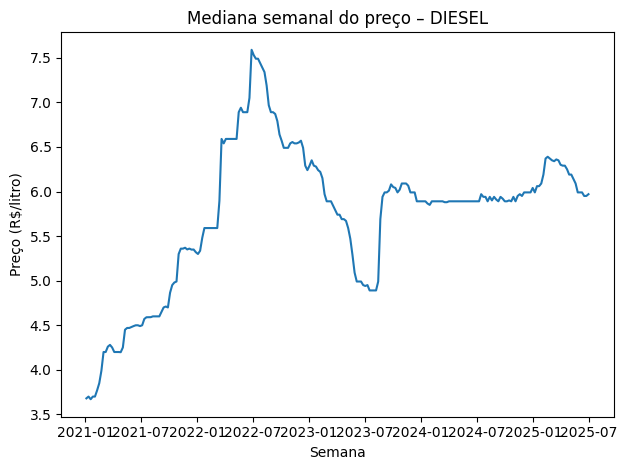

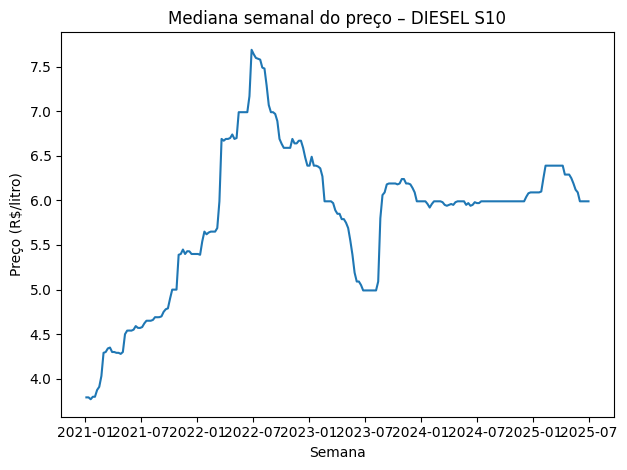

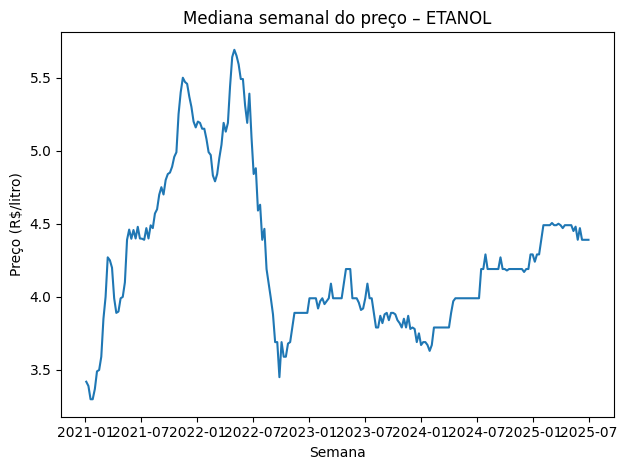

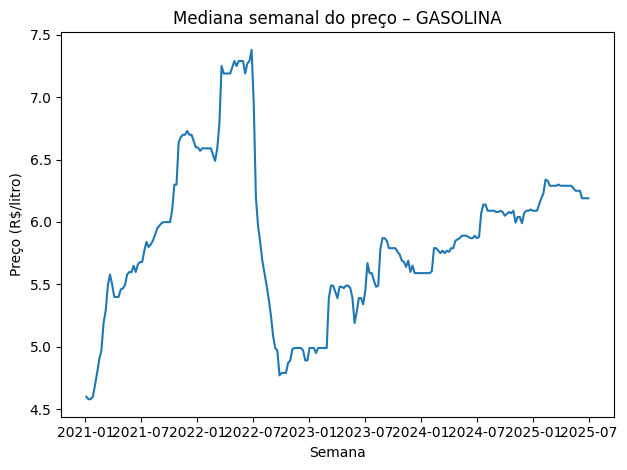

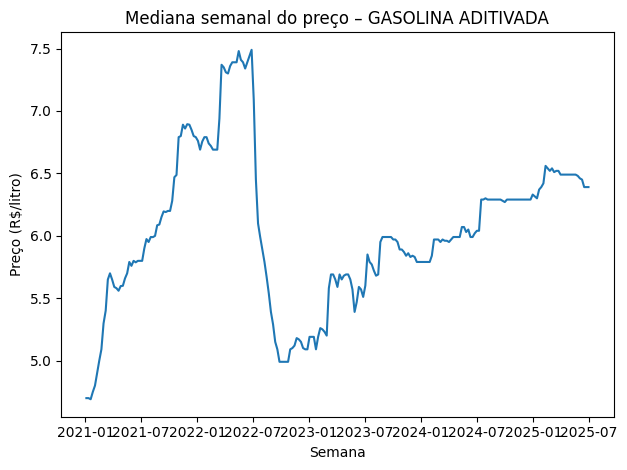

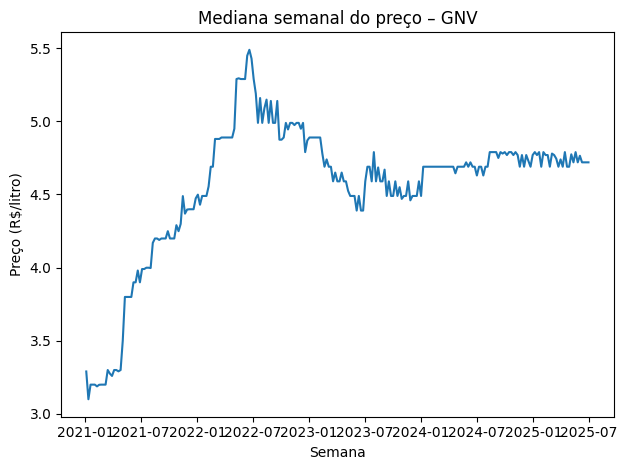


=== Outliers (regra IQR) nas medianas semanais por produto ===
           produto  level_1  mediana_preco
            DIESEL       q1         5.3270
            DIESEL       q3         6.1900
            DIESEL      iqr         0.8630
            DIESEL  lim_inf         4.0325
            DIESEL  lim_sup         7.4845
            DIESEL outliers        12.0000
        DIESEL S10       q1         5.3990
        DIESEL S10       q3         6.2800
        DIESEL S10      iqr         0.8810
        DIESEL S10  lim_inf         4.0775
        DIESEL S10  lim_sup         7.6015
        DIESEL S10 outliers        10.0000
            ETANOL       q1         3.8900
            ETANOL       q3         4.4900
            ETANOL      iqr         0.6000
            ETANOL  lim_inf         2.9900
            ETANOL  lim_sup         5.3900
            ETANOL outliers        11.0000
          GASOLINA       q1         5.4900
          GASOLINA       q3         6.1900
          GASOLINA      iqr      

<Figure size 640x480 with 0 Axes>

In [18]:
# =========================================================
# 4) Diagnósticos simples por Produto
#    - Sazonalidade/Autocorrelação: correlograma (semanas)
#    - Tendência visual: gráfico de linha
#    - Outliers: regra IQR sobre as medianas semanais
# =========================================================

import math

produtos = weekly["produto"].dropna().unique()

# (4a) Gráficos de série temporal (1 por produto)
for p in produtos:
    serie = weekly.loc[weekly["produto"] == p, ["semana","mediana_preco"]].dropna()
    if serie.empty:
        continue
    plt.figure()
    plt.plot(serie["semana"], serie["mediana_preco"])
    plt.title(f"Mediana semanal do preço – {p}")
    plt.xlabel("Semana")
    plt.ylabel("Preço (R$/litro)")
    plt.tight_layout()
    plt.show()

# (4b) Outliers via IQR nas medianas semanais (por produto)
def outlier_iqr(x):
    x = x.dropna()
    if x.empty:
        return pd.Series({"q1":np.nan,"q3":np.nan,"iqr":np.nan,"lim_inf":np.nan,"lim_sup":np.nan,"outliers":0})
    q1 = np.nanpercentile(x, 25)
    q3 = np.nanpercentile(x, 75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5*iqr
    lim_sup = q3 + 1.5*iqr
    n_out = ((x < lim_inf) | (x > lim_sup)).sum()
    return pd.Series({"q1":q1,"q3":q3,"iqr":iqr,"lim_inf":lim_inf,"lim_sup":lim_sup,"outliers":int(n_out)})

out_stats = weekly.groupby("produto")["mediana_preco"].apply(outlier_iqr).reset_index()
print("\n=== Outliers (regra IQR) nas medianas semanais por produto ===")
print(out_stats.to_string(index=False))

# (4c) Correlograma simples (autocorrelação) – requer statsmodels (opcional)
try:
    from statsmodels.tsa.stattools import acf
    for p in produtos:
        serie = weekly.loc[weekly["produto"] == p, ["semana","mediana_preco"]].dropna()
        if len(serie) < 10:
            continue
        # ordena por tempo e pega somente valores
        y = serie.sort_values("semana")["mediana_preco"].values
        # até 52 defasagens (1 ano aproximadamente)
        nlags = min(52, len(y)-2)
        if nlags <= 1:
            continue
        acf_vals = acf(y, nlags=nlags, fft=True, missing="conservative")
        plt.figure()
        plt.stem(range(len(acf_vals)), acf_vals, use_line_collection=True)
        plt.title(f"ACF das medianas semanais – {p}")
        plt.xlabel("Defasagem (semanas)")
        plt.ylabel("Autocorrelação")
        plt.tight_layout()
        plt.show()
except Exception as e:
    print("\n[AVISO] statsmodels não disponível para ACF. Para ver correlogramas, instale: pip install statsmodels")
    print(f"Detalhes: {e}")

In [19]:
df.head(1)

,regiao,uf,municipio,revenda,cnpj,logradouro,numero,complemento,bairro,cep,produto,data,preco_venda,preco_compra,unidade,bandeira,ano,mes_dt,sem_dt
0,SE,SP,SOROCABA,COMPETRO COMERCIO E DISTRIBUICAO DE DERIVADOS ...,00.003.188/0001-21,RUA HUMBERTO DE CAMPOS,306,None,JARDIM ZULMIRA,18061-000,GASOLINA,2023-07-03,4.87,NaN,R$ / litro,BRANCA,2023,2023-07-01,2023-06-27


In [20]:
# =========================================================
# 5) Corte temporal para modelagem (treino <= 2024-12-31; teste = 2025)
#    Aqui só preparamos as partes; a regressão virá depois.
# =========================================================

lim_treino = pd.Timestamp("2024-12-31")
lim_teste_ini = pd.Timestamp("2025-01-01")
lim_teste_fim = pd.Timestamp("2025-06-30")

weekly["particao"] = np.where(
    weekly["semana"] <= lim_treino, "treino",
    np.where((weekly["semana"] >= lim_teste_ini) & (weekly["semana"] <= lim_teste_fim), "teste_2025H1", "fora")
)

resumo_particao = weekly.pivot_table(index="produto", columns="particao", values="mediana_preco", aggfunc="count").fillna(0).astype(int)
print("\n=== Contagem de semanas por partição (treino/teste) ===")
print(resumo_particao.to_string())

# Salva a base já com a partição marcada
weekly.to_csv("out/mediana_semanal_por_produto_com_particao.csv", index=False, encoding="utf-8")
print("\nArquivos gerados:")
print(f"- {weekly_path.resolve()}")
print(f"- {Path('out/mediana_semanal_por_produto_com_particao.csv').resolve()}")


=== Contagem de semanas por partição (treino/teste) ===
particao            teste_2025H1  treino
produto                                 
DIESEL                        26     209
DIESEL S10                    26     209
ETANOL                        26     209
GASOLINA                      26     209
GASOLINA ADITIVADA            26     209
GNV                           26     209

Arquivos gerados:
- /home/mari/tcc_lubricants_anp/out/mediana_semanal_por_produto.csv
- /home/mari/tcc_lubricants_anp/out/mediana_semanal_por_produto_com_particao.csv


In [ ]:
df.head(1)

,regiao,uf,municipio,revenda,produto,data,preco_venda,preco_compra,unidade,bandeira,ano,mes_dt,sem_dt
0,SE,SP,SOROCABA,COMPETRO COMERCIO E DISTRIBUICAO DE DERIVADOS ...,GASOLINA,2023-07-03,4.87,NaN,R$ / litro,BRANCA,2023,2023-07-01,2023-06-27


In [21]:
# limpando as colunas que nao  vao agregar como dummies no modelo
df = df.drop(columns=['logradouro', 'numero', 'complemento', 'bairro', 'cep', 'revenda'])

In [22]:
TARGET      = "preco_venda"   # alvo (ex.: 'venda_mediana', 'venda_media', 'preco_venda', etc.)
COL_TIME    = "sem_dt"          # coluna temporal (ex.: 'sem_dt' semanal, 'mes_dt' mensal, 'data' no nível diário)
CAT_VARS    = ["produto"]       # variáveis categóricas a codificar (adicione 'uf','bandeira' se fizer sentido)
NUM_EXTRAS  = []                # variáveis numéricas adicionais (ex.: 't', 'lag1' se você quiser incluir manualmente)

TARGET_LOG  = True              # usar log(alvo) para estabilizar variância
RARE_MIN_N  = 10     


if COL_TIME in df.columns:
    df[COL_TIME] = pd.to_datetime(df[COL_TIME], errors="coerce")

# Remover registros sem alvo ou tempo
df = df.dropna(subset=[TARGET, COL_TIME]).copy()

# Limpeza básica de categorias (trim/upper)
for c in CAT_VARS:
    df[c] = (
        df[c]
        .astype(str)
        .str.strip()
        .replace({"None": np.nan, "nan": np.nan})
    )

# Tratar níveis raros: colapsa níveis com contagem < RARE_MIN_N para "OUTROS"
for c in CAT_VARS:
    vc = df[c].value_counts(dropna=False)
    raros = set(vc[vc < RARE_MIN_N].index.tolist())
    if len(raros) > 0:
        df[c] = df[c].where(~df[c].isin(raros), other="OUTROS")

# Tendência temporal (dias desde o início) — ajuda na especificação
t0 = df[COL_TIME].min()
df["t"] = (df[COL_TIME] - t0).dt.days.astype("int32")
if "t" not in NUM_EXTRAS:
    NUM_EXTRAS = ["t"] + NUM_EXTRAS

# Transformação do alvo
if TARGET_LOG:
    df = df[df[TARGET] > 0].copy()
    df["log_y"] = np.log(df[TARGET])
    Y = "log_y"
else:
    Y = TARGET

In [24]:
# ======================== 2) CATEGORIAS COM REFERÊNCIA (one-hot) ========================
# Definir referências como o nível mais frequente de cada categoria
ref_map = {}
for c in CAT_VARS:
    ref_map[c] = df[c].mode().iloc[0] if df[c].notna().any() else None

# Construção da fórmula com referências explícitas (Treatment)
# Ex.: log_y ~ t + C(produto, Treatment('GASOLINA')) + C(uf, Treatment('SP')) + ...
def term_cat(col, ref):
    return f"C({col}, Treatment(reference='{ref}'))" if ref is not None else f"C({col})"

rhs_terms = []
# numéricos
rhs_terms.extend(NUM_EXTRAS)
# categóricos com referência
rhs_terms.extend([term_cat(c, ref_map[c]) for c in CAT_VARS])

formula = f"{Y} ~ " + " + ".join(rhs_terms)
print("[Fórmula OLS]:", formula)

[Fórmula OLS]: log_y ~ t + C(produto, Treatment(reference='GASOLINA'))


In [25]:
# ======================== 3) AJUSTE DO MODELO ========================
model = smf.ols(formula, data=df).fit()  # p-values clássicos
# Para erros robustos, reestime com cov robusta (opcional):
model_rob = smf.ols(formula, data=df).fit(cov_type="HC3")

print("\n=== Resumo OLS (clássico) — cabeçalho ===")
print(model.summary().tables[0])
print("\n=== Resumo OLS (robusto HC3) — R² e N ===")
print(f"R²: {model_rob.rsquared:.4f} | R² adj.: {model_rob.rsquared_adj:.4f} | n={int(model_rob.nobs)}")


=== Resumo OLS (clássico) — cabeçalho ===
                            OLS Regression Results                            
Dep. Variable:                  log_y   R-squared:                       0.468
Model:                            OLS   Adj. R-squared:                  0.468
Method:                 Least Squares   F-statistic:                 5.769e+05
Date:                Sat, 18 Oct 2025   Prob (F-statistic):               0.00
Time:                        17:05:46   Log-Likelihood:             2.1152e+06
No. Observations:             3937984   AIC:                        -4.230e+06
Df Residuals:                 3937977   BIC:                        -4.230e+06
Df Model:                           6                                         
Covariance Type:            nonrobust                                         

=== Resumo OLS (robusto HC3) — R² e N ===
R²: 0.4678 | R² adj.: 0.4678 | n=3937984



[Durbin–Watson] 1.03  (≈2: ok; <<2 autocorr+; >>2 autocorr−)
[Breusch–Pagan]  stat=176132.45, p=0  (p<0.05 sugere heterocedasticidade)
[White]          stat=783808.06, p=0    (p<0.05 sugere heterocedasticidade)
[Jarque–Bera]    stat=14096.09, p=0, skew=0.005, kurt=3.293


<Figure size 500x500 with 0 Axes>

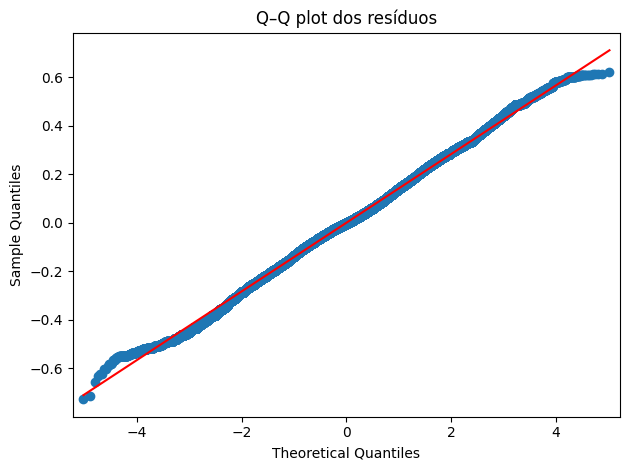

In [27]:
# ======================== 4) DIAGNÓSTICOS ========================
# Resíduos e ajustados
resid   = model.resid
fitted  = model.fittedvalues
X_design = model.model.exog      # matriz de regressoras (inclui intercepto)
X_names  = model.model.exog_names

# 4.1 Independência (Durbin–Watson)
dw = sm.stats.stattools.durbin_watson(resid)
print(f"\n[Durbin–Watson] {dw:.2f}  (≈2: ok; <<2 autocorr+; >>2 autocorr−)")

# 4.2 Homocedasticidade (Breusch–Pagan e White)
bp_stat, bp_p, _, _ = het_breuschpagan(resid, sm.add_constant(fitted))
w_stat, w_p, _, _   = het_white(resid, X_design)
print(f"[Breusch–Pagan]  stat={bp_stat:.2f}, p={bp_p:.4g}  (p<0.05 sugere heterocedasticidade)")
print(f"[White]          stat={w_stat:.2f}, p={w_p:.4g}    (p<0.05 sugere heterocedasticidade)")

# 4.3 Normalidade (Jarque–Bera + Q–Q)
jb_stat, jb_p, skew, kurt = jarque_bera(resid)
print(f"[Jarque–Bera]    stat={jb_stat:.2f}, p={jb_p:.4g}, skew={skew:.3f}, kurt={kurt:.3f}")
plt.figure(figsize=(5,5))
sm.ProbPlot(resid.dropna()).qqplot(line="s")
plt.title("Q–Q plot dos resíduos")
plt.tight_layout(); plt.show()



In [28]:
# 4.4 Multicolinearidade (VIF) — exceto intercepto
vif_df = []
for i, name in enumerate(X_names):
    if name.lower() in ["intercept", "const"]:
        continue
    try:
        vif_val = VIF(X_design, i)
        vif_df.append({"variavel": name, "VIF": float(vif_val)})
    except Exception:
        pass
vif_df = pd.DataFrame(vif_df).sort_values("VIF", ascending=False)
print("\n[VIF] top 15:")
print(vif_df.head(15))


plt.tight_layout(); plt.show()


[VIF] top 15:
                                            variavel       VIF
2  C(produto, Treatment(reference='GASOLINA'))[T....  1.451408
3  C(produto, Treatment(reference='GASOLINA'))[T....  1.418977
1  C(produto, Treatment(reference='GASOLINA'))[T....  1.415381
0  C(produto, Treatment(reference='GASOLINA'))[T....  1.278066
4  C(produto, Treatment(reference='GASOLINA'))[T....  1.057357
5                                                  t  1.000706


<Figure size 640x480 with 0 Axes>

In [33]:
# 4.5 Influência: Cook’s distance, leverage (h_ii), resíduos studentizados
infl = model.get_influence()
cooks = infl.cooks_distance[0]
hat   = infl.hat_matrix_diag
stud  = infl.resid_studentized_external

influ_df = pd.DataFrame({
    "cooks_d": cooks,
    "leverage": hat,
    "stud_resid": stud,
    Y: df[Y].values if Y in df.columns else np.nan
}).reset_index(drop=True)
# Top observações influentes
print("\n[Top 10 influência] (Cook’s distance):")
print(influ_df.sort_values("cooks_d", ascending=False).head(10))

KeyboardInterrupt: 

In [30]:
# 4.6 Especificação (Ramsey RESET) — indica termos omitidos / má especificação
reset_res = linear_reset(model, power=2, use_f=True)  # inclui quadrático de fitted
print(f"\n[Ramsey RESET] F={reset_res.fvalue:.2f}, p={reset_res.pvalue:.4g}  (p<0.05 sugere má especificação)")


[Ramsey RESET] F=136822.71, p=0  (p<0.05 sugere má especificação)


Text(0.5, 1.0, 'Resíduos vs Ajustados')

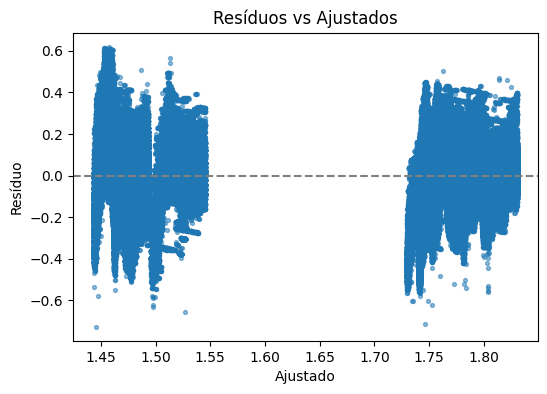

In [31]:
# 4.7 Resíduos vs Ajustados (homocedasticidade visual)
plt.figure(figsize=(6,4))
plt.scatter(fitted, resid, s=8, alpha=0.5)
plt.axhline(0, linestyle="--", color="gray")
plt.xlabel("Ajustado"); plt.ylabel("Resíduo")
plt.title("Resíduos vs Ajustados")

In [32]:
# ======================== 5) SAÚDE DOS DADOS (tamanho amostra & NA’s) ========================
print("\n[Contagem por nível — primeiras 10 categorias por variável]")
for c in CAT_VARS:
    print(f"\n{c}:")
    print(df[c].value_counts(dropna=False).head(10))

# Observações x nº de parâmetros
n_obs = int(model.nobs)
n_params = int(len(model.params))
print(f"\n[Dimensão] n_obs={n_obs:,} | n_parâmetros={n_params:,}  (regra: n_obs > #dummies total)")

# NA's
print("\n[NA's por coluna — top 10]:")
na_counts = df.isna().sum().sort_values(ascending=False)
print(na_counts.head(10))

# ======================== 6) DICAS DE AJUSTE (prints) ========================
print("\n=== Interpretação rápida ===")
print("- Se BP/White p<0.05 → heterocedasticidade: reporte erros robustos (HC3) e/ou mantenha alvo em log.")
print("- Se DW muito longe de 2 → autocorrelação: considere incluir termos de defasagem (lag) ou modelos de tempo.")
print("- Se JB p<0.05, Q–Q curvado → resíduos não normais: com n grande, p-values ainda ok; prefira ICs robustos.")
print("- VIF alto (>10) → multicolinearidade: remova/una níveis raros, reduza dummies, ou regularize (Ridge).")
print("- Cook’s/leverage altos → investigue observações; verifique outliers de entrada (dados).")
print("- RESET p<0.05 → termos omitidos: tente interações (ex.: C(produto):t) ou sazonalidade extra.")
print("\nUse model_rob (HC3) para inferência robusta:")
print("  model_rob = smf.ols(formula, data=df).fit(cov_type='HC3')")



[Contagem por nível — primeiras 10 categorias por variável]

produto:
produto
GASOLINA              1009159
ETANOL                 871975
GASOLINA ADITIVADA     771882
DIESEL S10             760119
DIESEL                 444870
GNV                     79979
Name: count, dtype: int64

[Dimensão] n_obs=3,937,984 | n_parâmetros=7  (regra: n_obs > #dummies total)

[NA's por coluna — top 10]:
preco_compra    3937984
uf                    0
regiao                0
cnpj                  0
produto               0
data                  0
municipio             0
preco_venda           0
unidade               0
bandeira              0
dtype: int64

=== Interpretação rápida ===
- Se BP/White p<0.05 → heterocedasticidade: reporte erros robustos (HC3) e/ou mantenha alvo em log.
- Se DW muito longe de 2 → autocorrelação: considere incluir termos de defasagem (lag) ou modelos de tempo.
- Se JB p<0.05, Q–Q curvado → resíduos não normais: com n grande, p-values ainda ok; prefira ICs robustos.
- VIF alto

In [45]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt

# ===================== 1) Carregar dados =====================
ARQ = "/home/mari/tcc_lubricants_anp/out/mediana_semanal_por_produto_com_particao.csv"
OUTDIR = Path("/home/mari/tcc_lubricants_anp/out/mediana_semanal_por_produto")
OUTDIR.mkdir(parents=True, exist_ok=True)

# alvo correto conforme seus CSVs
TARGET = "mediana_preco"

# lê com a coluna de semana em datetime
dfw = pd.read_csv(ARQ, parse_dates=["semana"])

# padroniza nomes para usar igual no restante do pipeline
dfw = dfw.rename(columns={
    "semana": "sem_dt",
    "n_observacoes": "n",
    "mediana_preco": "venda_mediana"  # alias interno do alvo
})

# garante que a coluna alvo exista (aceitando tanto 'mediana_preco' quanto o alias)
tem_cols = {"produto", "sem_dt", "particao"}
assert tem_cols.issubset(dfw.columns), f"Colunas ausentes: {tem_cols - set(dfw.columns)}"
assert ("venda_mediana" in dfw.columns) or (TARGET in dfw.columns), "Coluna de alvo não encontrada."

# define qual coluna será usada como alvo no restante do código
if "venda_mediana" in dfw.columns:
    TARGET_COL = "venda_mediana"
else:
    TARGET_COL = TARGET  # fallback, se você preferir trabalhar direto com 'mediana_preco'

print("Shape:", dfw.shape)
print(dfw.head())
print("\nContagem por partição:")
print(dfw.groupby(["produto","particao"]).size().unstack(fill_value=0))


Shape: (1410, 5)
  produto     sem_dt  venda_mediana     n particao
0  DIESEL 2021-01-04          3.679   364   treino
1  DIESEL 2021-01-11          3.699   950   treino
2  DIESEL 2021-01-18          3.669   992   treino
3  DIESEL 2021-01-25          3.699   999   treino
4  DIESEL 2021-02-01          3.699  1119   treino

Contagem por partição:
particao            teste_2025H1  treino
produto                                 
DIESEL                        26     209
DIESEL S10                    26     209
ETANOL                        26     209
GASOLINA                      26     209
GASOLINA ADITIVADA            26     209
GNV                           26     209


In [47]:
# ===================== 2) Preparar lags + features de tempo =====================
# usa a coluna alvo correta (do bloco anterior)
target = "venda_mediana" if "venda_mediana" in dfw.columns else TARGET

dfw = dfw.sort_values(["produto", "sem_dt"]).copy()

# garante numérico e filtra valores positivos para o log
dfw[target] = pd.to_numeric(dfw[target], errors="coerce")
dfw = dfw.loc[dfw[target] > 0].copy()
dfw["log_y"] = np.log(dfw[target])

# lags (defasagens por produto)
dfw["log_y_lag1"] = dfw.groupby("produto")["log_y"].shift(1)
dfw["log_y_lag4"] = dfw.groupby("produto")["log_y"].shift(4)  # ~4 semanas (≈1 mês)

# remover linhas sem lag
dfw = dfw.dropna(subset=["log_y", "log_y_lag1"]).copy()

# tendência + Fourier leve
dfw["sem_dt"] = pd.to_datetime(dfw["sem_dt"], errors="coerce")
t0 = dfw["sem_dt"].min()
dfw["t"] = (dfw["sem_dt"] - t0).dt.days.astype("int32")

for k in (1, 2):
    omega = 2 * np.pi * k / 365.25
    dfw[f"F_sin{k}"] = np.sin(omega * dfw["t"])
    dfw[f"F_cos{k}"] = np.cos(omega * dfw["t"])


In [48]:
# ===================== 3) Split temporal (treino ≤ 2024-12-31; teste = 2025-H1) =====================
cutoff = pd.Timestamp("2024-12-31")
train = dfw.loc[dfw["sem_dt"] <= cutoff].copy()
test  = dfw.loc[dfw["sem_dt"] >  cutoff].copy()

# ===================== 4) Modelo OLS + HAC (Newey–West, maxlags=4 semanas) =====================
fourier_terms = " + ".join([f"F_sin{k} + F_cos{k}" for k in (1,2)])
formula = f"log_y ~ log_y_lag1 + log_y_lag4 + t + {fourier_terms} + C(produto)"

mod = smf.ols(formula, data=train).fit(cov_type="HAC",
                                       cov_kwds={"maxlags": 4, "use_correction": True})

# ===== Salvar COEFICIENTES (com erros padrão HAC) =====
coef_table = pd.DataFrame({
    "coef": mod.params,
    "std_err_HAC": mod.bse,
    "t": mod.tvalues,
    "p": mod.pvalues
})
coef_path = OUTDIR / "coeficientes_ols_hac.csv"
coef_table.to_csv(coef_path, float_format="%.6g")
print(f"[OK] Coeficientes salvos em: {coef_path}")

[OK] Coeficientes salvos em: /home/mari/tcc_lubricants_anp/out/mediana_semanal_por_produto/coeficientes_ols_hac.csv


In [56]:
# ===================== 5) Predições no TESTE + métricas + CSV =====================
# identifica a coluna do alvo (conforme padronização feita antes)
target_col = ("venda_mediana" if "venda_mediana" in test.columns
              else ("mediana_preco" if "mediana_preco" in test.columns else TARGET))

pred_log = mod.predict(test)
test = test.assign(
    y_obs=np.exp(test["log_y"]),
    y_hat=np.exp(pred_log),
    y_base=np.exp(test["log_y_lag1"])  # baseline: repetir semana anterior
)

# Métricas gerais (alinhado por índice)
idx  = test.index
MAE  = (test.loc[idx, "y_hat"]  - test.loc[idx, "y_obs"]).abs().mean()
RMSE = np.sqrt(((test.loc[idx, "y_hat"] - test.loc[idx, "y_obs"])**2).mean())
MAPE = ((test.loc[idx, "y_hat"] - test.loc[idx, "y_obs"]).abs() / test.loc[idx, "y_obs"]).mean() * 100

bMAE  = (test.loc[idx, "y_base"] - test.loc[idx, "y_obs"]).abs().mean()
bRMSE = np.sqrt(((test.loc[idx, "y_base"] - test.loc[idx, "y_obs"])**2).mean())
bMAPE = ((test.loc[idx, "y_base"] - test.loc[idx, "y_obs"]).abs() / test.loc[idx, "y_obs"]).mean() * 100

print(f"[TESTE 2025-H1] OLS+HAC:  MAE={MAE:.3f} RMSE={RMSE:.3f} MAPE={MAPE:.2f}%")
print(f"[Baseline lag1]           MAE={bMAE:.3f} RMSE={bRMSE:.3f} MAPE={bMAPE:.2f}%")

# Salvar CSV de previsões (uma linha por produto×semana)
# monta colunas presentes de forma robusta
pred_cols = ["produto", "sem_dt", "y_obs", "y_hat", "y_base"]
# inclui alvo observado original se existir
if target_col in test.columns:
    pred_cols.insert(2, target_col)
# inclui contagem se existir (pode ser 'n' ou 'n_observacoes')
if "n" in test.columns:
    pred_cols.append("n")
elif "n_observacoes" in test.columns:
    pred_cols.append("n_observacoes")

pred_path = OUTDIR / "predicoes_teste_2025H1.csv"
test.loc[:, pred_cols].to_csv(pred_path, index=False, date_format="%Y-%m-%d")
print(f"[OK] Predições salvas em: {pred_path}")


[TESTE 2025-H1] OLS+HAC:  MAE=0.034 RMSE=0.047 MAPE=0.62%
[Baseline lag1]           MAE=0.029 RMSE=0.047 MAPE=0.53%
[OK] Predições salvas em: /home/mari/tcc_lubricants_anp/out/mediana_semanal_por_produto/predicoes_teste_2025H1.csv


In [57]:
# ===================== 6) PLOTS por produto (obs vs prev vs baseline) =====================
# Equalizar escala Y para comparação justa (global dos testes)
ymin = float(test[["y_obs","y_hat","y_base"]].min().min())
ymax = float(test[["y_obs","y_hat","y_base"]].max().max())
pad  = 0.05*(ymax - ymin if ymax>ymin else 1.0)
ylims = (ymin - pad, ymax + pad)

for prod, g in test.groupby("produto"):
    g = g.sort_values("sem_dt")

    plt.figure(figsize=(10,5))
    plt.plot(g["sem_dt"], g["y_obs"], marker="o", linewidth=1.5, label="Observado")
    plt.plot(g["sem_dt"], g["y_hat"], marker="s", linestyle="--", linewidth=1.5, label="Previsto OLS+HAC")
    plt.plot(g["sem_dt"], g["y_base"], marker="^", linestyle=":", linewidth=1.5, label="Baseline lag1")
    plt.ylim(*ylims)
    plt.title(f"Preço semanal — {prod} (Teste 2025-H1)")
    plt.xlabel("Semana"); plt.ylabel("R$/L")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()

    fig_path = OUTDIR / f"plot_teste_2025H1_{prod.replace(' ','_')}.png"
    plt.savefig(fig_path, dpi=150)
    plt.close()
    print(f"[OK] Plot salvo: {fig_path}")

[OK] Plot salvo: /home/mari/tcc_lubricants_anp/out/mediana_semanal_por_produto/plot_teste_2025H1_DIESEL.png
[OK] Plot salvo: /home/mari/tcc_lubricants_anp/out/mediana_semanal_por_produto/plot_teste_2025H1_DIESEL_S10.png
[OK] Plot salvo: /home/mari/tcc_lubricants_anp/out/mediana_semanal_por_produto/plot_teste_2025H1_ETANOL.png
[OK] Plot salvo: /home/mari/tcc_lubricants_anp/out/mediana_semanal_por_produto/plot_teste_2025H1_GASOLINA.png
[OK] Plot salvo: /home/mari/tcc_lubricants_anp/out/mediana_semanal_por_produto/plot_teste_2025H1_GASOLINA_ADITIVADA.png
[OK] Plot salvo: /home/mari/tcc_lubricants_anp/out/mediana_semanal_por_produto/plot_teste_2025H1_GNV.png


In [58]:
# ===================== 7) (Opcional) Relatório de métricas por produto =====================
per_prod = (
    test.groupby("produto")
        .apply(lambda d: pd.Series({
            "MAE":  (d["y_hat"] - d["y_obs"]).abs().mean(),
            "RMSE": np.sqrt(((d["y_hat"] - d["y_obs"])**2).mean()),
            "MAPE": ((d["y_hat"] - d["y_obs"]).abs()/d["y_obs"]).mean()*100,
            "MAE_base":  (d["y_base"] - d["y_obs"]).abs().mean(),
            "RMSE_base": np.sqrt(((d["y_base"] - d["y_obs"])**2).mean()),
            "MAPE_base": ((d["y_base"] - d["y_obs"]).abs()/d["y_obs"]).mean()*100,
            "n_sem": len(d)
        }))
        .reset_index()
)
per_prod_path = OUTDIR / "metricas_por_produto.csv"
per_prod.to_csv(per_prod_path, index=False, float_format="%.6g")
print(f"[OK] Métricas por produto salvas em: {per_prod_path}")


[OK] Métricas por produto salvas em: /home/mari/tcc_lubricants_anp/out/mediana_semanal_por_produto/metricas_por_produto.csv


In [60]:
formula = "log_y ~ log_y_lag1 + log_y_lag2 + log_y_lag4 + t + " \
          + " + ".join([f"F_sin{k} + F_cos{k}" for k in (1,2)]) \
          + " + C(produto) + C(produto):t"
train = train.assign(
    log_y_lag2=train.groupby("produto")["log_y"].shift(2)
).dropna(subset=["log_y_lag2"])
mod = smf.ols(formula, data=train).fit(cov_type="HAC", cov_kwds={"maxlags":4, "use_correction":True})


=== Resumo (enxuto) ===
R²=0.9911 | R²_adj=0.9909 | n=1230
  log_y_lag1: coef= 1.1574  se(HAC)= 0.0505  p=4.44e-116
  log_y_lag2: coef=-0.1170  se(HAC)= 0.0679  p=0.0847
  log_y_lag4: coef=-0.0663  se(HAC)= 0.0240  p=0.00578
           t: coef=-0.0000  se(HAC)= 0.0000  p=0.997

Durbin–Watson (train): 2.01  (≈2 ideal; <2 autocorr+)

TREINO: MAE=0.055  RMSE=0.093  MAPE=1.06%
TESTE : MAE=0.036  RMSE=0.049  MAPE=0.67%
BASE  : MAE=0.029  RMSE=0.048  MAPE=0.54%

=== Métricas por produto (teste) ===
              produto    MAE   RMSE   MAPE  MAE_base  RMSE_base  MAPE_base  n_sem
0              DIESEL  0.036  0.049  0.586     0.035      0.054      0.557   24.0
1          DIESEL S10  0.032  0.050  0.521     0.029      0.055      0.469   24.0
2              ETANOL  0.036  0.050  0.813     0.025      0.043      0.573   24.0
3            GASOLINA  0.026  0.035  0.422     0.017      0.032      0.280   24.0
4  GASOLINA ADITIVADA  0.028  0.039  0.428     0.020      0.037      0.315   24.0
5        

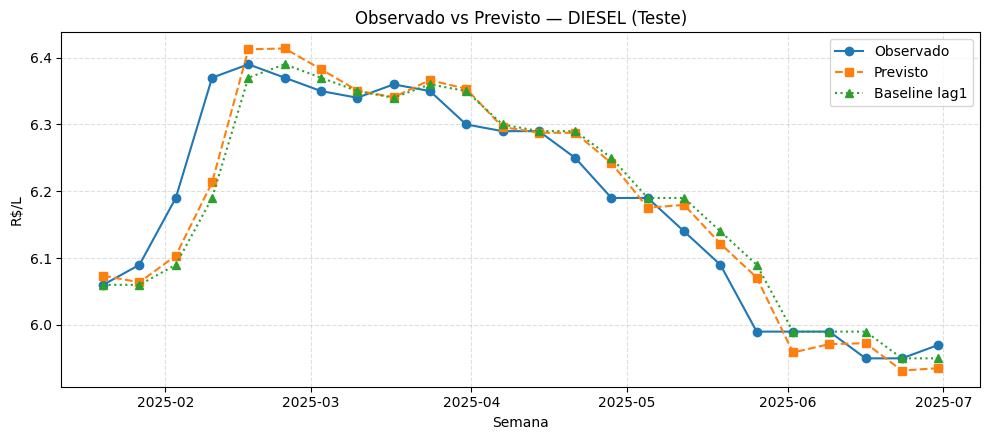

In [61]:
# ===================== Verificação do modelo =====================
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 0) Garante que o teste também tenha lag2 e sem NaN nesses regressores:
for df_ in (train, test):
    if "log_y_lag2" not in df_.columns:
        df_.sort_values(["produto","sem_dt"], inplace=True)
        df_["log_y_lag2"] = df_.groupby("produto")["log_y"].shift(2)

req_cols = ["log_y","log_y_lag1","log_y_lag2","log_y_lag4","t","F_sin1","F_cos1","F_sin2","F_cos2","produto"]
train_eval = train.dropna(subset=req_cols).copy()
test_eval  = test.dropna(subset=req_cols).copy()

# 1) Resumo rápido do ajuste (HAC já foi usado no fit)
print("\n=== Resumo (enxuto) ===")
print(f"R²={mod.rsquared:.4f} | R²_adj={mod.rsquared_adj:.4f} | n={int(mod.nobs)}")
for k in ["log_y_lag1","log_y_lag2","log_y_lag4","t"]:
    if k in mod.params.index:
        print(f"{k:>12}: coef={mod.params[k]: .4f}  se(HAC)={mod.bse[k]: .4f}  p={mod.pvalues[k]:.3g}")

# 2) DW (autocorrelação dos resíduos in-sample)
dw = sm.stats.stattools.durbin_watson(mod.resid)
print(f"\nDurbin–Watson (train): {dw:.2f}  (≈2 ideal; <2 autocorr+)")

# 3) Métricas — TREINO
pred_tr_log = mod.predict(train_eval)
yhat_tr = np.exp(pred_tr_log)
y_tr    = np.exp(train_eval["log_y"])
MAE_tr  = (yhat_tr - y_tr).abs().mean()
RMSE_tr = np.sqrt(((yhat_tr - y_tr)**2).mean())
MAPE_tr = ((yhat_tr - y_tr).abs()/y_tr).mean()*100
print(f"\nTREINO: MAE={MAE_tr:.3f}  RMSE={RMSE_tr:.3f}  MAPE={MAPE_tr:.2f}%")

# 4) Métricas — TESTE
pred_te_log = mod.predict(test_eval)
yhat_te = np.exp(pred_te_log)
y_te    = np.exp(test_eval["log_y"])
MAE_te  = (yhat_te - y_te).abs().mean()
RMSE_te = np.sqrt(((yhat_te - y_te)**2).mean())
MAPE_te = ((yhat_te - y_te).abs()/y_te).mean()*100
print(f"TESTE : MAE={MAE_te:.3f}  RMSE={RMSE_te:.3f}  MAPE={MAPE_te:.2f}%")

# 5) Baseline lag1 no TESTE
y_naive = np.exp(test_eval["log_y_lag1"])
bMAE  = (y_naive - y_te).abs().mean()
bRMSE = np.sqrt(((y_naive - y_te)**2).mean())
bMAPE = ((y_naive - y_te).abs()/y_te).mean()*100
print(f"BASE  : MAE={bMAE:.3f}  RMSE={bRMSE:.3f}  MAPE={bMAPE:.2f}%")

# 6) Métricas por produto (útil para ver quem ganha/perde do baseline)
per_prod = (
    pd.DataFrame({
        "produto": test_eval["produto"].values,
        "y": y_te.values,
        "yhat": yhat_te.values,
        "ybase": y_naive.values
    })
    .groupby("produto")
    .apply(lambda d: pd.Series({
        "MAE": (d["yhat"]-d["y"]).abs().mean(),
        "RMSE": np.sqrt(((d["yhat"]-d["y"])**2).mean()),
        "MAPE": ((d["yhat"]-d["y"]).abs()/d["y"]).mean()*100,
        "MAE_base": (d["ybase"]-d["y"]).abs().mean(),
        "RMSE_base": np.sqrt(((d["ybase"]-d["y"])**2).mean()),
        "MAPE_base": ((d["ybase"]-d["y"]).abs()/d["y"]).mean()*100,
        "n_sem": len(d)
    }))
    .reset_index()
)
print("\n=== Métricas por produto (teste) ===")
print(per_prod.round(3))

# 7) (Opcional) Gráfico rápido de um produto
um_prod = test_eval["produto"].iloc[0]
g = test_eval.loc[test_eval["produto"]==um_prod].sort_values("sem_dt")
plt.figure(figsize=(10,4.5))
plt.plot(g["sem_dt"], np.exp(g["log_y"]), marker="o", label="Observado")
plt.plot(g["sem_dt"], np.exp(mod.predict(g)), marker="s", linestyle="--", label="Previsto")
plt.plot(g["sem_dt"], np.exp(g["log_y_lag1"]), marker="^", linestyle=":", label="Baseline lag1")
plt.title(f"Observado vs Previsto — {um_prod} (Teste)")
plt.xlabel("Semana"); plt.ylabel("R$/L"); plt.grid(True, linestyle="--", alpha=.4)
plt.legend(); plt.tight_layout(); plt.show()
